In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

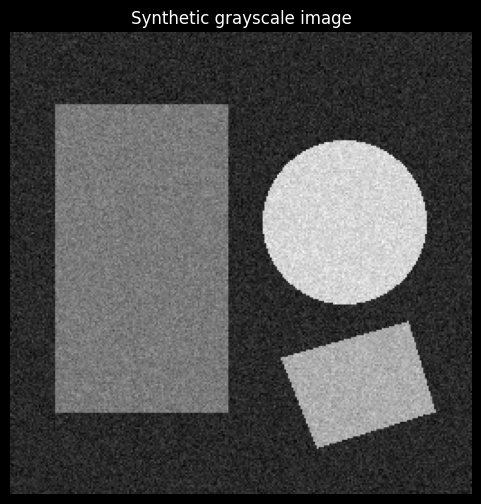

In [3]:
def create_synthetic_image(size=(256, 256), noise_level=12):
    width, height = size
    img = Image.new("L", size, color=40)
    draw = ImageDraw.Draw(img)

    # medium rectangle
    draw.rectangle((25, 40, 120, 210), fill=120)

    # bright circle
    draw.ellipse((140, 60, 230, 150), fill=210)

    # slanted bright bar
    draw.polygon([(150, 180), (220, 160), (235, 210), (170, 230)], fill=170)

    arr = np.array(img).astype(np.float32)

    # add noise
    noise = np.random.normal(loc=0, scale=noise_level, size=arr.shape)
    arr = np.clip(arr + noise, 0, 255)

    return arr.astype(np.uint8)

image = create_synthetic_image()

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Synthetic grayscale image")
plt.axis("off")
plt.show()

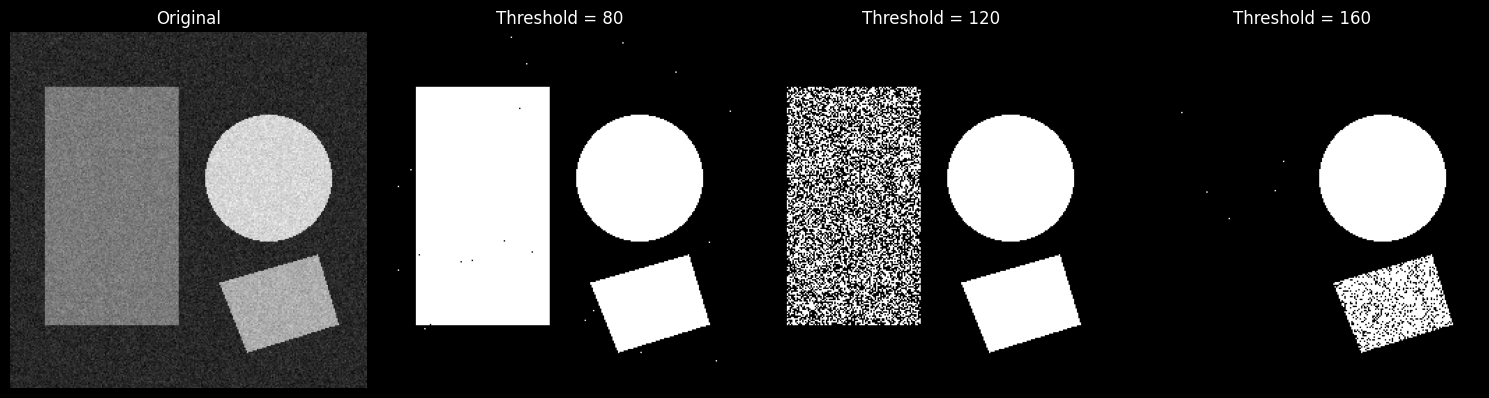

In [4]:
def global_threshold(img, T):
    return (img >= T).astype(np.uint8)

thresholds = [80, 120, 160]

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, T in enumerate(thresholds):
    mask = global_threshold(image, T)
    axes[i+1].imshow(mask, cmap='gray')
    axes[i+1].set_title(f'Threshold = {T}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

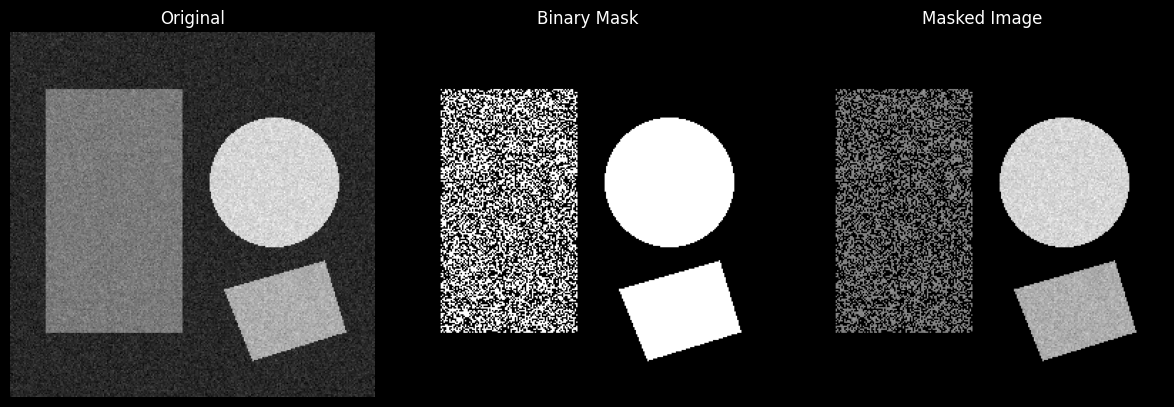

In [5]:
mask = global_threshold(image, 120)

# Apply mask to original image
masked_image = image * mask

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Binary Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_image, cmap='gray')
plt.title('Masked Image')
plt.axis('off')

plt.tight_layout()
plt.show()

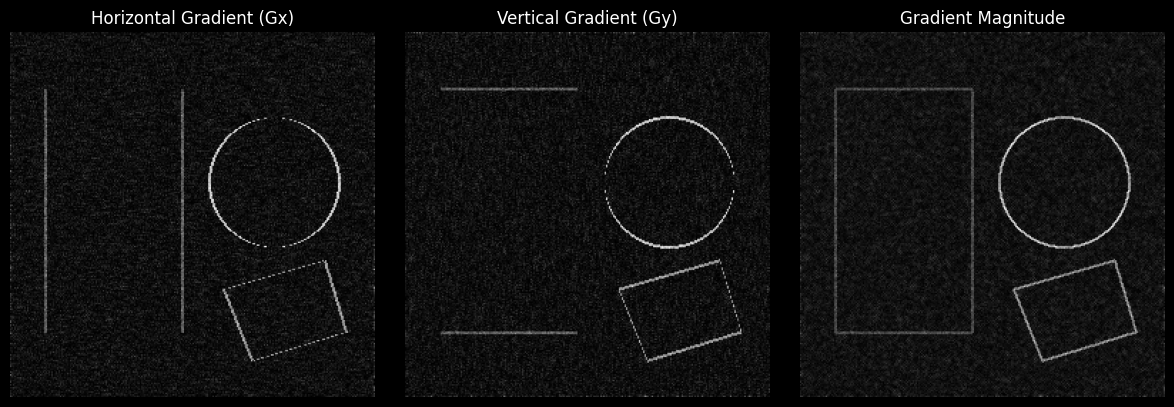

In [6]:
# Compute gradients
grad_x = np.gradient(image.astype(float), axis=1)
grad_y = np.gradient(image.astype(float), axis=0)

# Gradient magnitude
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Normalize for display
gradient_magnitude_norm = (gradient_magnitude / gradient_magnitude.max() * 255).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(np.abs(grad_x), cmap='gray')
plt.title('Horizontal Gradient (Gx)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.abs(grad_y), cmap='gray')
plt.title('Vertical Gradient (Gy)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gradient_magnitude_norm, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

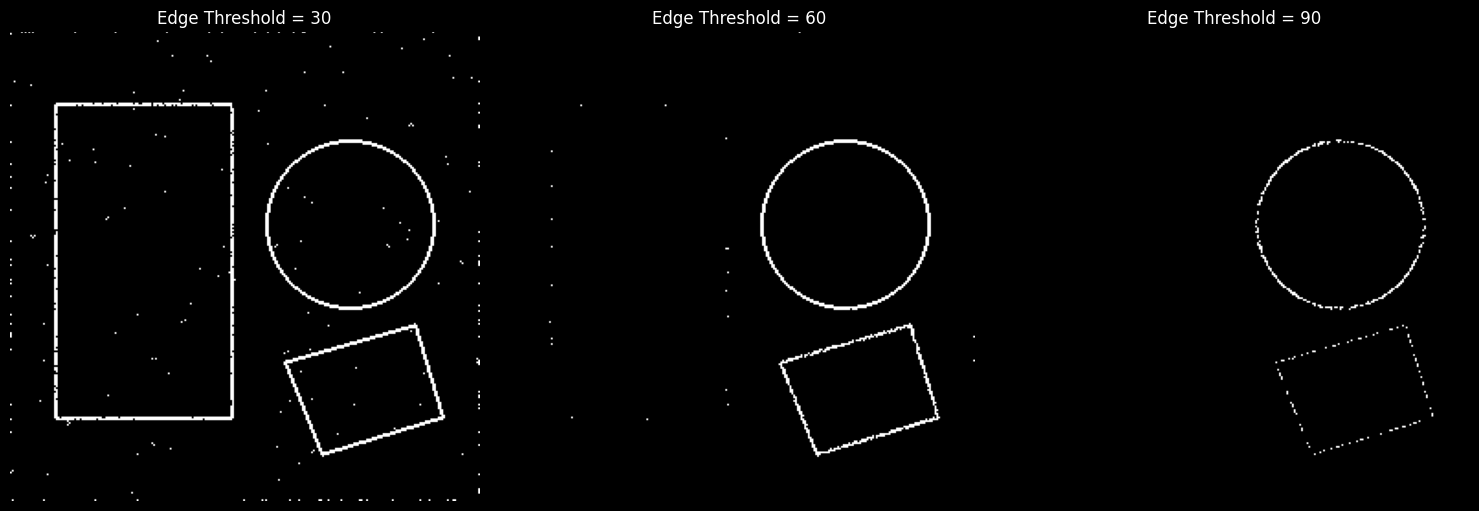

In [7]:
edge_thresholds = [30, 60, 90]

fig, axes = plt.subplots(1, len(edge_thresholds), figsize=(15, 5))

for ax, thr in zip(axes, edge_thresholds):
    edge_map = (gradient_magnitude >= thr).astype(np.uint8)
    ax.imshow(edge_map, cmap='gray')
    ax.set_title(f'Edge Threshold = {thr}')
    ax.axis('off')

plt.tight_layout()
plt.show()